In [1]:
from ms2x import MS2X
from matchms.importing import load_from_msp

from rdkit.Chem.Draw import MolsToGridImage
from rdkit.Chem import MolFromSmiles

from tqdm import tqdm

In [2]:
ms2x = MS2X()

## Spectra based

In [3]:
test_spectra = "sulfonylurea_eawag_massbank.msp"

In [4]:
all_substructures = []
all_fragments = []
all_subformulas = []
all_smiles = []
for spec in tqdm(load_from_msp(test_spectra)):
    substructures, subformulas = ms2x.approximate_substructure(spec)
    all_substructures.append(substructures)
    all_subformulas.append(subformulas)
    all_smiles.append(spec.get("smiles"))
    all_fragments.append(spec.peaks.mz.round(2).astype('str'))

124it [00:42,  2.91it/s]


In [5]:
example_i = 0

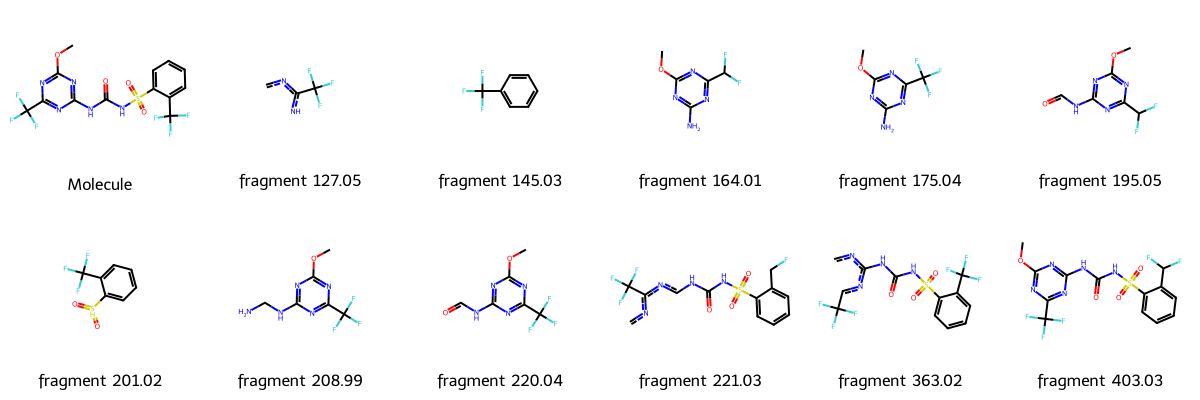

In [6]:
MolsToGridImage(
    [MolFromSmiles(all_smiles[example_i])] + all_substructures[example_i],
    legends = ["Molecule"] + ["fragment "+frag for frag in all_fragments[example_i]],
    molsPerRow=6
           )

## Fragment based

In [7]:
tebuconazole = "CC(C)(C)C(CCC1=CC=C(C=C1)Cl)(CN2C=NC=N2)O"

In [8]:
substructure_1, subformula_1 = ms2x.approximate_substructure_by_fragments([70.0400], tebuconazole)

In [9]:
substructure_2, subformula_2 = ms2x.approximate_substructure_by_fragments([151.0309], tebuconazole)

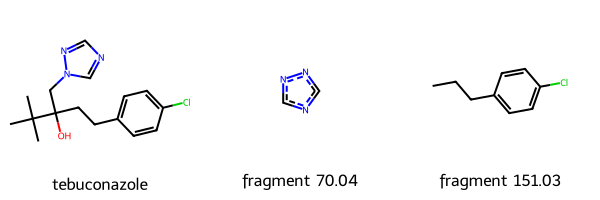

In [10]:
MolsToGridImage(
    [MolFromSmiles(tebuconazole)] + substructure_1 + substructure_2,
    legends = ["tebuconazole", "fragment 70.04", "fragment 151.03"]
           )